In [96]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
from scipy import signal

pd.set_option('display.max_columns', None)

In [97]:
test = json.loads(open('../info.json', 'r', encoding='utf-8').read()).get('test') 
test

1

In [98]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)

# DADOS MEASURE

In [ ]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

def convertAxis(df):    
    for col in ['ax', 'ay', 'az']:
        df[col] = df[col] / 1000000.0 * 9.80665

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df

,wz,az,yaw,ax,h,time,pitch,ay,wx,wy,roll,tmp
0,-0.02252,9.786821,1.551,-0.173754,-0.024,7.152557e-07,0.0074,-0.270526,-0.04969,0.10067,0.00386,43.8
1,-0.00236,9.779888,1.565,-0.171538,-0.022,9.435034e-02,0.0094,-0.258072,0.07862,0.01753,-0.00114,43.7
2,-0.04887,9.791499,1.572,-0.157554,-0.019,2.007830e-01,0.0064,-0.248520,-0.11278,-0.06852,-0.00714,43.8
3,-0.01132,9.768649,1.578,-0.169537,-0.017,2.974703e-01,0.0064,-0.275959,-0.04654,0.03072,-0.00814,43.7
4,-0.02012,9.781780,1.592,-0.161339,-0.014,4.027123e-01,-0.0006,-0.270291,-0.00709,-0.01811,-0.00014,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
17022,-0.05596,9.790587,24.694,-0.195751,-0.006,1.702951e+03,0.0864,-0.244539,-0.02678,0.09952,0.13186,44.6
17023,-0.10312,9.772209,24.696,-0.198349,-0.006,1.703046e+03,0.0874,-0.253227,-0.06341,0.04221,0.13286,44.8
17024,0.02902,9.783653,24.698,-0.202625,-0.006,1.703146e+03,0.0864,-0.246510,0.05080,0.04384,0.13186,44.7
17025,-0.01943,9.777573,24.699,-0.191897,-0.006,1.703249e+03,0.0854,-0.236007,-0.05271,-0.05613,0.13186,44.7


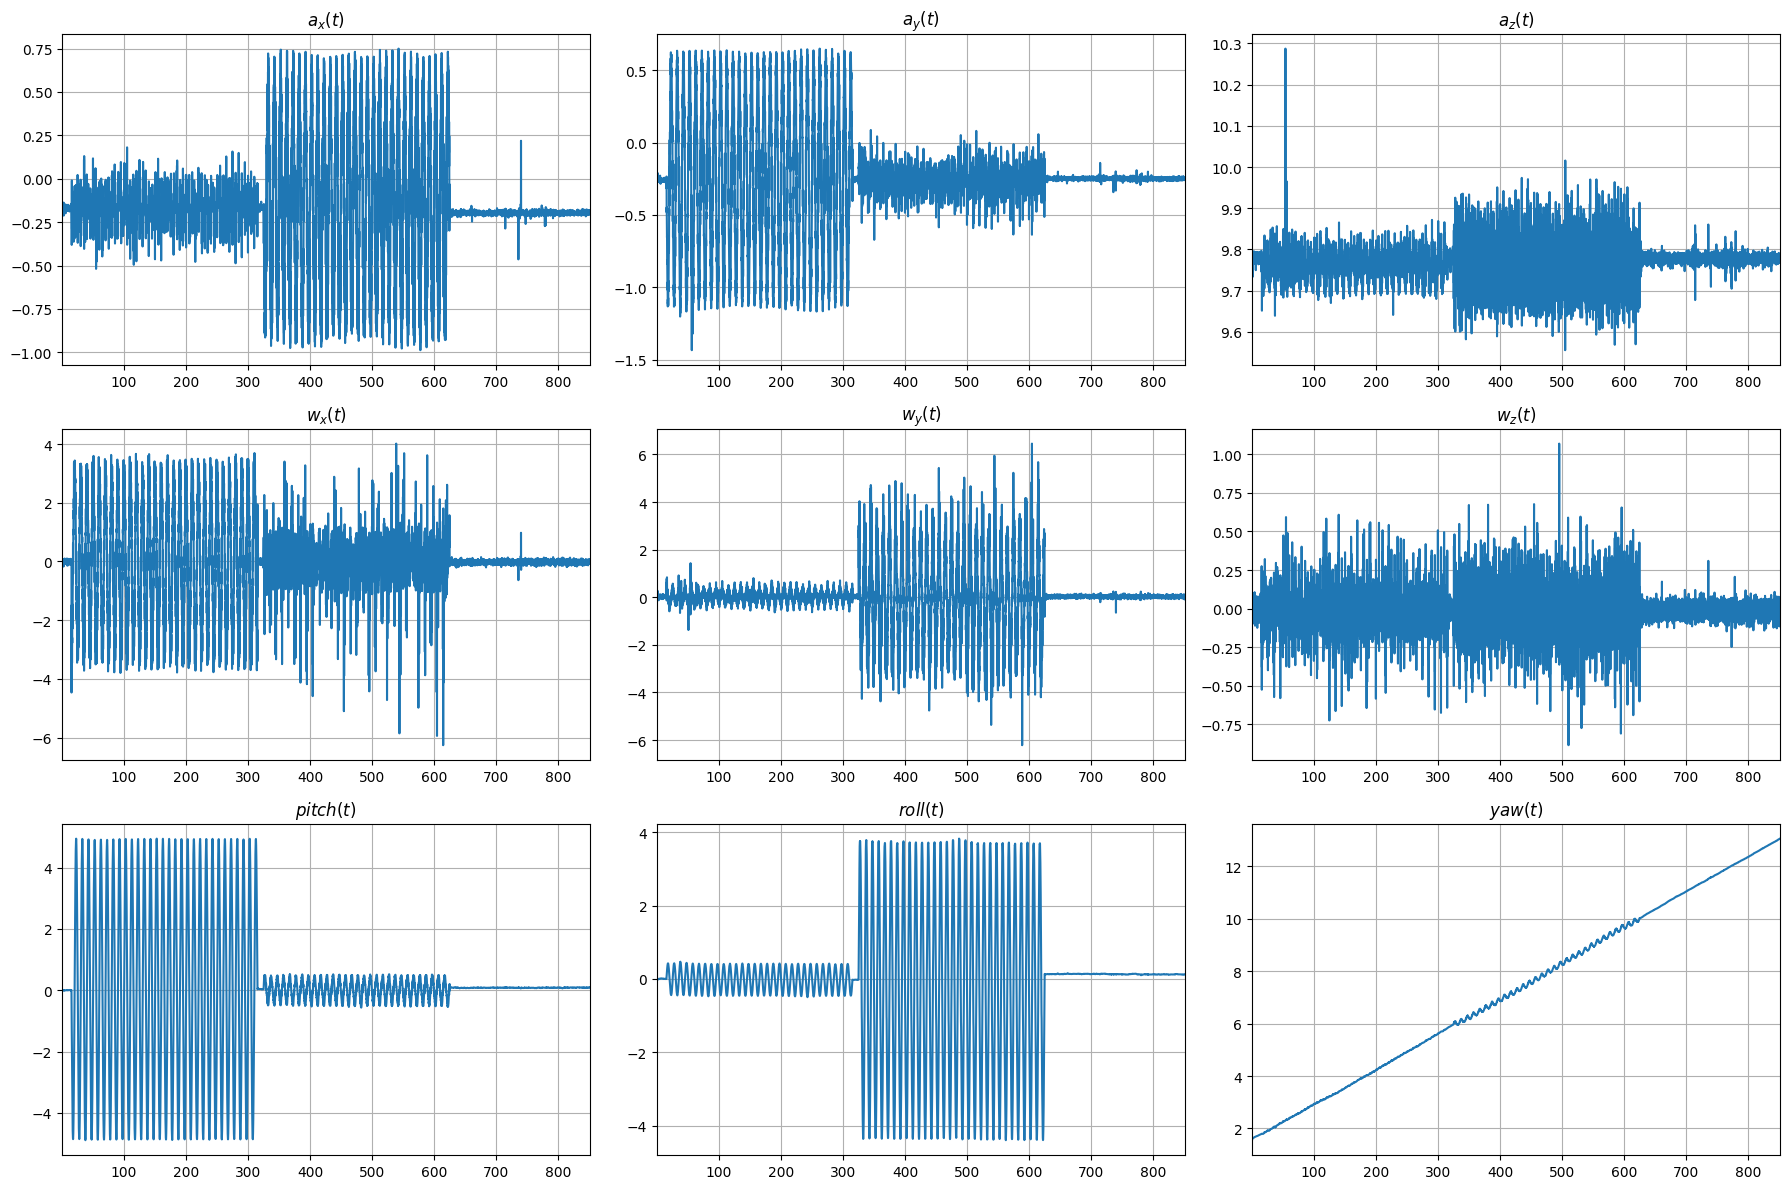

In [100]:
df_target = pd.read_csv(f'files/test{test}/target/data.csv')
df_target = convertAxis(df_target)

df_target['pitch'] = df_target['pitch'] - df_target['pitch'].values[:50].mean()
df_target['roll'] = df_target['roll'] - df_target['roll'].values[:50].mean()

display(df_target)

plotAll(df_target, limits=(0, 0.5))

### FUSÃO

Text(0.5, 1.0, 'roll calculated')

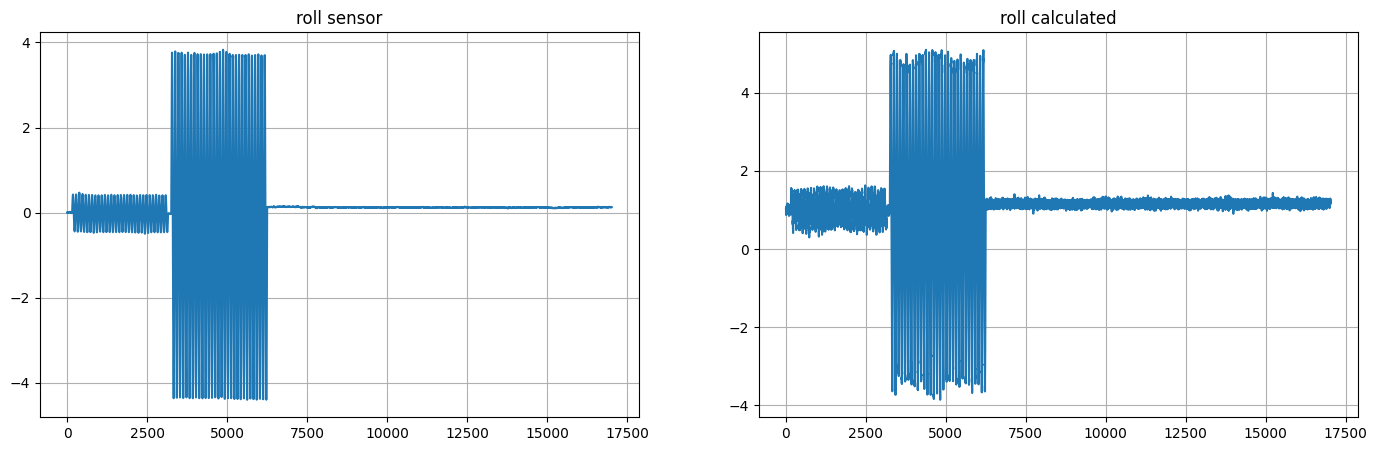

In [101]:
class OrientationParser:
    def __init__(self, beta=0.01, accel_min=0.1, accel_max=20, dt_min=1e-6, dt_max=0.15):
        self.q0, self.q1, self.q2, self.q3 = 1.0, 0.0, 0.0, 0.0
        self.beta      = beta
        self.accel_min = accel_min
        self.accel_max = accel_max
        self.dt_min    = dt_min
        self.dt_max    = dt_max
        self.yaw       = 0.0
        self.pitch     = 0.0
        self.roll      = 0.0
        self._initialized = False

    def start(self, ax, ay, az):
        norm = math.sqrt(ax*ax + ay*ay + az*az)
        if norm < self.accel_min:
            return  # leitura inválida, fica em identidade
        ax /= norm; ay /= norm; az /= norm

        if az >= 0.0:
            denom = math.sqrt(2.0 * (az + 1.0))
            if denom < 1e-10:
                return
            self.q0 =  denom / 2.0
            self.q1 =  ay / denom  # convencione: -ay se seu eixo for invertido
            self.q2 = -ax / denom
            self.q3 =  0.0
        else:
            denom = math.sqrt(2.0 * (1.0 - az))
            if denom < 1e-10:
                return
            self.q0 =  ay / denom
            self.q1 =  denom / 2.0
            self.q2 =  0.0
            self.q3 =  ax / denom

        rn = self._recipnorm4(self.q0, self.q1, self.q2, self.q3)
        if rn is not None:
            self.q0 *= rn; self.q1 *= rn
            self.q2 *= rn; self.q3 *= rn
        self._initialized = True


    def update(self, gx, gy, gz, ax, ay, az, dt):
        dt = max(self.dt_min, min(dt, self.dt_max))
        q0, q1, q2, q3 = self.q0, self.q1, self.q2, self.q3

        # 2. Derivada do quaternion pelo giroscópio
        qDot1 = 0.5 * (-q1*gx - q2*gy - q3*gz)
        qDot2 = 0.5 * ( q0*gx + q2*gz - q3*gy)
        qDot3 = 0.5 * ( q0*gy - q1*gz + q3*gx)
        qDot4 = 0.5 * ( q0*gz + q1*gy - q2*gx)

        # 3. Correção pelo acelerômetro (Madgwick gradient descent)
        accel_norm = math.sqrt(ax*ax + ay*ay + az*az)
        
        # Aceita apenas se a norma está dentro da janela "gravidade dominante"
        # accel_max rejeita amostras em vibração/movimento brusco (> 2g)
        if self.accel_min < accel_norm < self.accel_max:
            inv = 1.0 / accel_norm
            ax *= inv; ay *= inv; az *= inv

            q0q0 = q0*q0; q1q1 = q1*q1
            q2q2 = q2*q2; q3q3 = q3*q3
            _2q0 = 2.0*q0; _2q1 = 2.0*q1
            _2q2 = 2.0*q2; _2q3 = 2.0*q3
            _4q0 = 4.0*q0; _4q1 = 4.0*q1; _4q2 = 4.0*q2
            _8q1 = 8.0*q1; _8q2 = 8.0*q2

            s0 = _4q0*q2q2 + _2q2*ax + _4q0*q1q1 - _2q1*ay
            s1 = (_4q1*q3q3 - _2q3*ax
                  + 4.0*q0q0*q1 - _2q0*ay
                  - _4q1 + _8q1*q1q1 + _8q1*q2q2 + _4q1*az)
            s2 = (4.0*q0q0*q2 + _2q0*ax
                  + _4q2*q3q3 - _2q3*ay
                  - _4q2 + _8q2*q1q1 + _8q2*q2q2 + _4q2*az)
            s3 = 4.0*q1q1*q3 - _2q1*ax + 4.0*q2q2*q3 - _2q2*ay

            rn = self._recipnorm4(s0, s1, s2, s3)
            if rn is not None:
                qDot1 -= self.beta * s0 * rn
                qDot2 -= self.beta * s1 * rn
                qDot3 -= self.beta * s2 * rn
                qDot4 -= self.beta * s3 * rn

        # 4. Integração de Euler de 1ª ordem
        q0 += qDot1 * dt
        q1 += qDot2 * dt
        q2 += qDot3 * dt
        q3 += qDot4 * dt

        # 5. Renormaliza — se degenerar, reinicia para identidade
        rn = self._recipnorm4(q0, q1, q2, q3)
        if rn is None:
            self.q0, self.q1, self.q2, self.q3 = 1.0, 0.0, 0.0, 0.0
            return
        self.q0 = q0 * rn
        self.q1 = q1 * rn
        self.q2 = q2 * rn
        self.q3 = q3 * rn

        self._compute_euler()

    # ------------------------------------------------------------------
    # Extração de ângulos de Euler (convenção ZYX / NED)
    # Roll (X) → Pitch (Y) → Yaw (Z)
    # ------------------------------------------------------------------
    def _compute_euler(self):
        q0, q1, q2, q3 = self.q0, self.q1, self.q2, self.q3

        # Yaw — corrigido: denominador usa q1²+q2², não q1²+q3²
        self.yaw = math.atan2(
            2.0*(q1*q2 - q0*q3),
            1.0 - 2.0*(q1*q1 + q2*q2)
        ) * (180.0 / math.pi)

        # Pitch — clamp explícito antes do asin (evita NaN por float noise)
        sinp = 2.0*(q2*q3 + q0*q1)
        self.pitch = math.asin(max(-1.0, min(1.0, sinp))) * (180.0 / math.pi)

        # Roll — negado para convenção NED
        self.roll = -math.atan2(
            2.0*(q1*q3 - q0*q2),
            1.0 - 2.0*(q1*q1 + q2*q2)
        ) * (180.0 / math.pi)

    # ------------------------------------------------------------------
    # Auxiliar — retorna 1/‖v‖ ou None se ‖v‖ < 1e-10 (portável para C++)
    # ------------------------------------------------------------------
    @staticmethod
    def _recipnorm4(a, b, c, d):
        n = a*a + b*b + c*c + d*d
        if n < 1e-10:
            return None
        return 1.0 / math.sqrt(n)



df  = df_target.copy()
var = 'roll'

parser = OrientationParser()
parser.start(df.iloc[0].ax, df.iloc[0].ay, df.iloc[0].az)

prev_time = df.time.values[0]
values    = list()

for _, row in df.iterrows():
    dt = (row.time - prev_time)
    prev_time = row.time
    wx, wy, wz = (np.pi/180.0*row.wx), (np.pi/180.0*row.wy), (np.pi/180.0*row.wz) 
    ax, ay, az = row.ax, row.ay, row.az
    parser.update(wx, wy, wz, ax, ay, az, dt)
    values.append([parser.pitch, parser.roll, parser.yaw])

df['calc_pitch'] = [pitch for (pitch, roll, yaw) in values]
df['calc_roll']  = [roll  for (pitch, roll, yaw) in values]
df['calc_yaw']   = [yaw   for (pitch, roll, yaw) in values]

plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
df[var].plot(); plt.grid()
plt.title(f'{var} sensor')

plt.subplot(1, 2, 2)
df[f'calc_{var}'].plot(); plt.grid()
plt.title(f'{var} calculated')

### FILTROS

0.1
testing ax


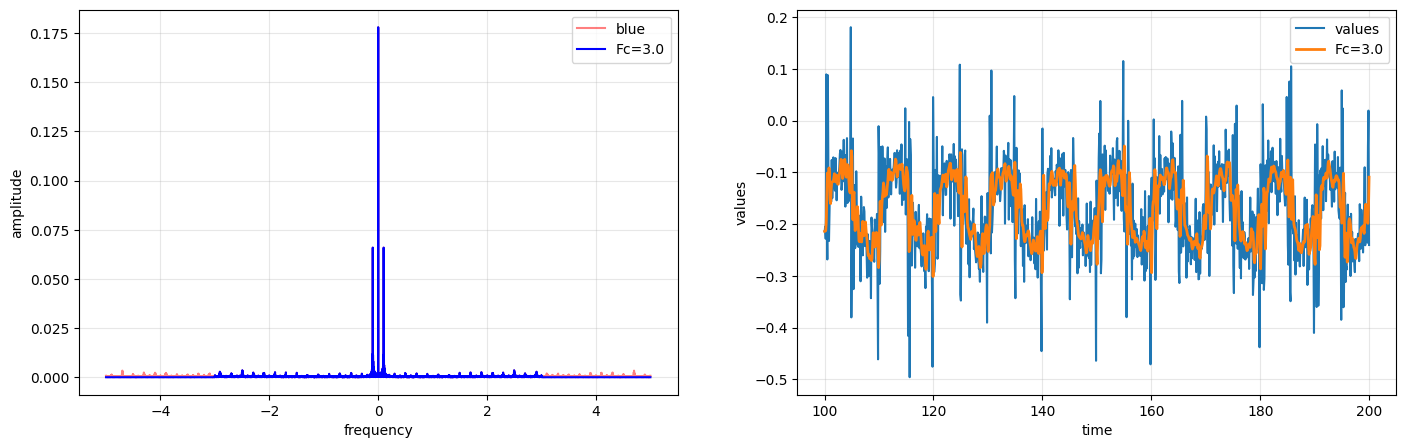

testing ay


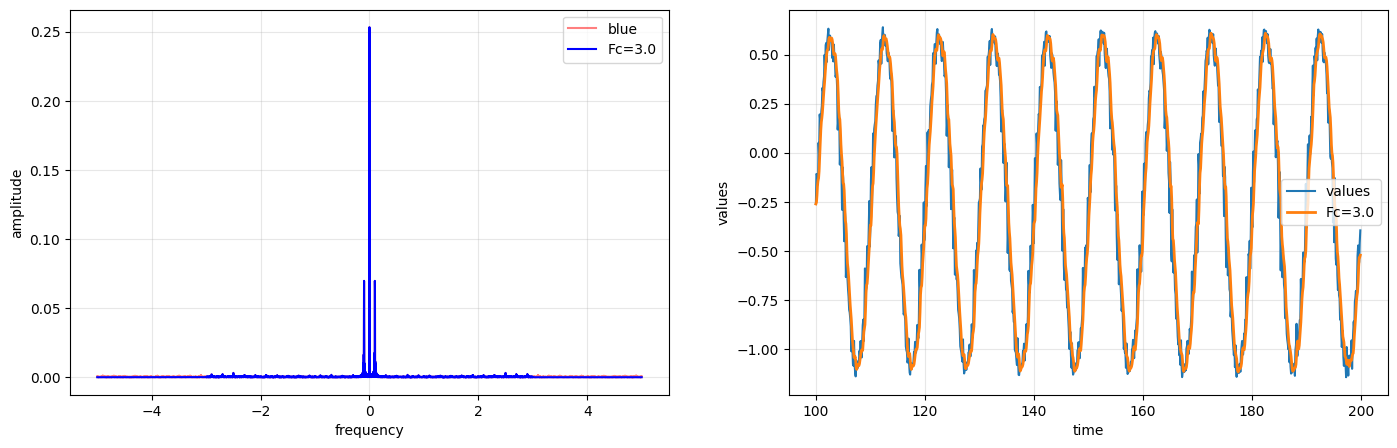

testing az


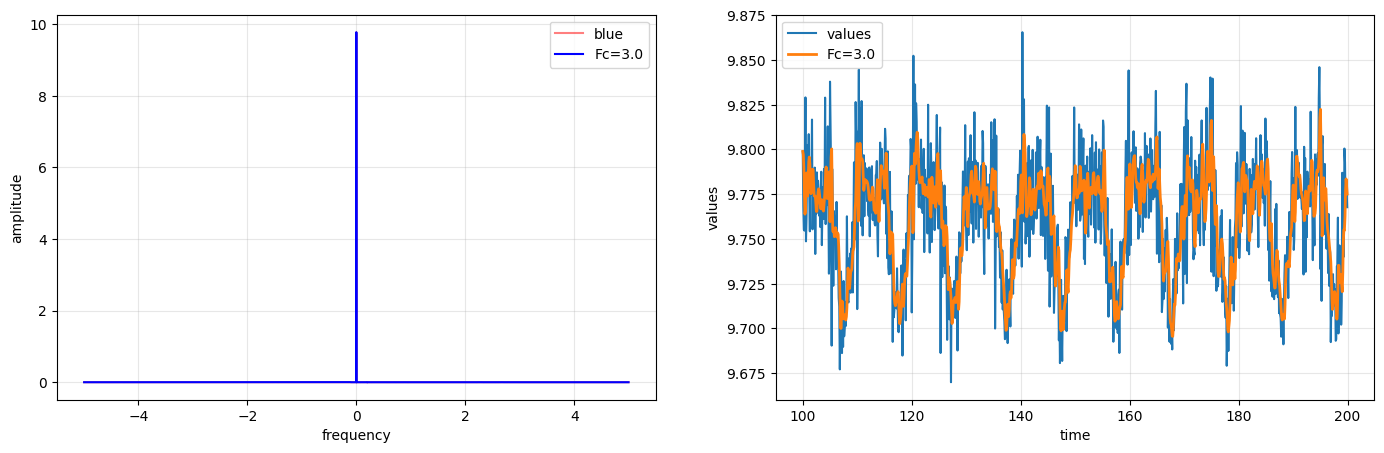

testing wx


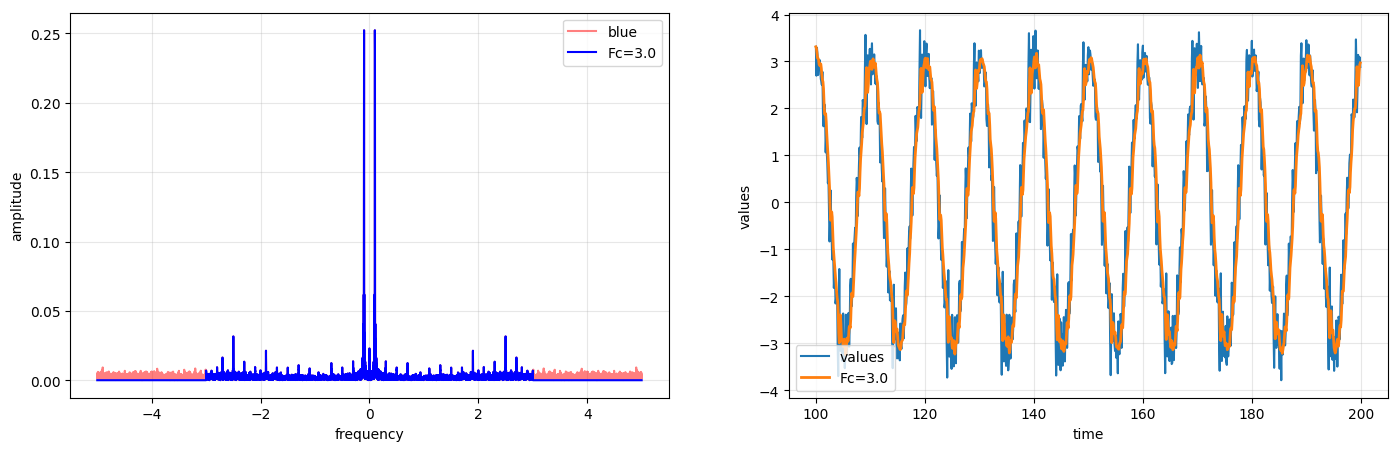

testing wy


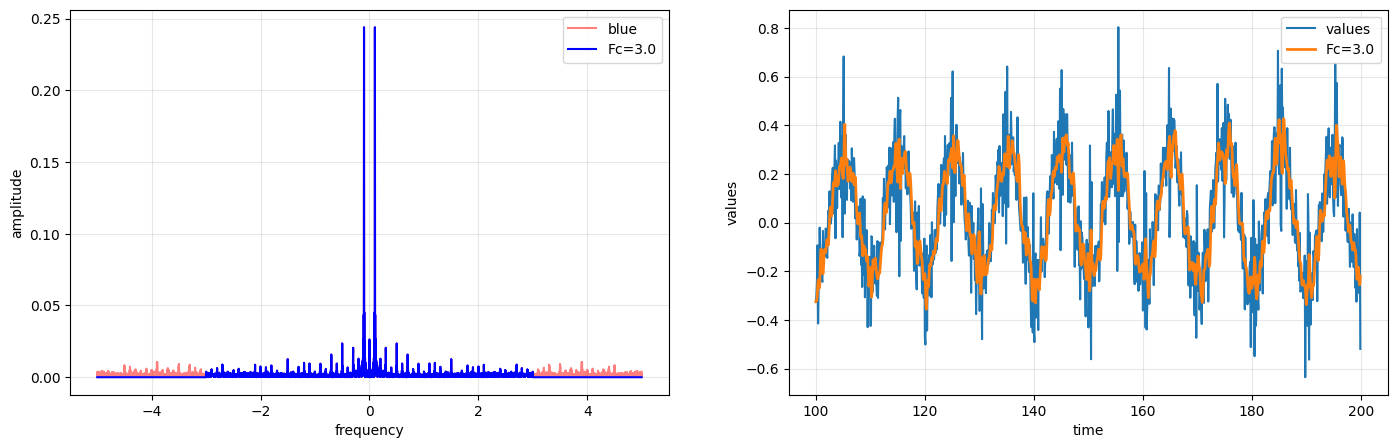

testing wz


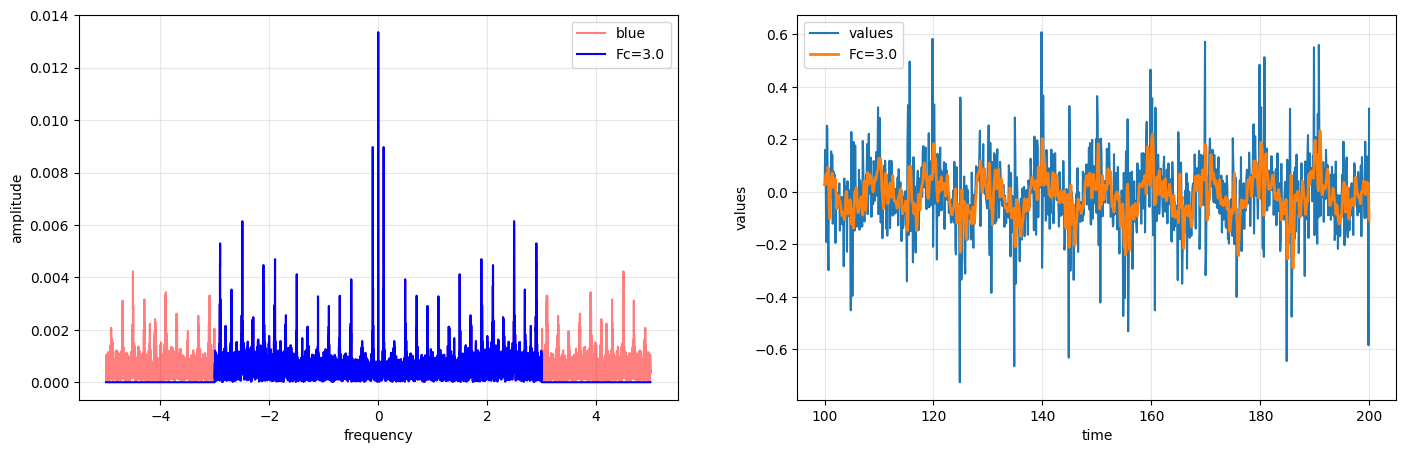

In [102]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()
        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc)
        num_c = [Wc**4]
        den_c = [1, 4*Wc, 6*(Wc**2), 4*(Wc**3), Wc**4]
        
        C = signal.cont2discrete((num_c, den_c), dt, method='bilinear')
        self.num, self.den = self.getFraction(C)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, C):
        num = np.squeeze(C[0])
        den = np.squeeze(C[1])
        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        yData = np.array(yData)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        
        if len(yData) > 0 and self.Fc > 0:
            for i in range(100): 
                self.update(yData[0])
        
        return np.array([self.update(val) for val in yData])

    def test(self, df, var, xLim, yLim, limits=(0, 100)):
        plt.figure(figsize=(17, 5))
        
        plt.subplot(1, 2, 1)
        print('testing', var)
        FrequencyAnalyzer(df.time, df[var]).plot(xLim, yLim, Fc=self.Fc)

        plt.subplot(1, 2, 2)
        target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]
        plt.plot(target.time, target[var], label='values')
        plt.plot(target.time, self.apply(target[var]), label=f'Fc={self.Fc}', linewidth=2)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.xlabel('time')
        plt.ylabel('values')
        plt.show()
        df[var] = self.apply(df[var])
        return df.copy()


dt     = round((df_target.time.values[2] - df_target.time.values[0])/2, 2)
limits = (100, 200) 
print(dt)

for var in ['ax', 'ay', 'az']:
    df = LowPassFilter(Fc=3.0, dt=dt).test(df_target, var, xLim=None, yLim=None, limits=limits)

for var in ['wx', 'wy', 'wz']:
    df = LowPassFilter(Fc=3.0, dt=dt).test(df_target, var, xLim=None, yLim=None, limits=limits)

# DADOS MESA

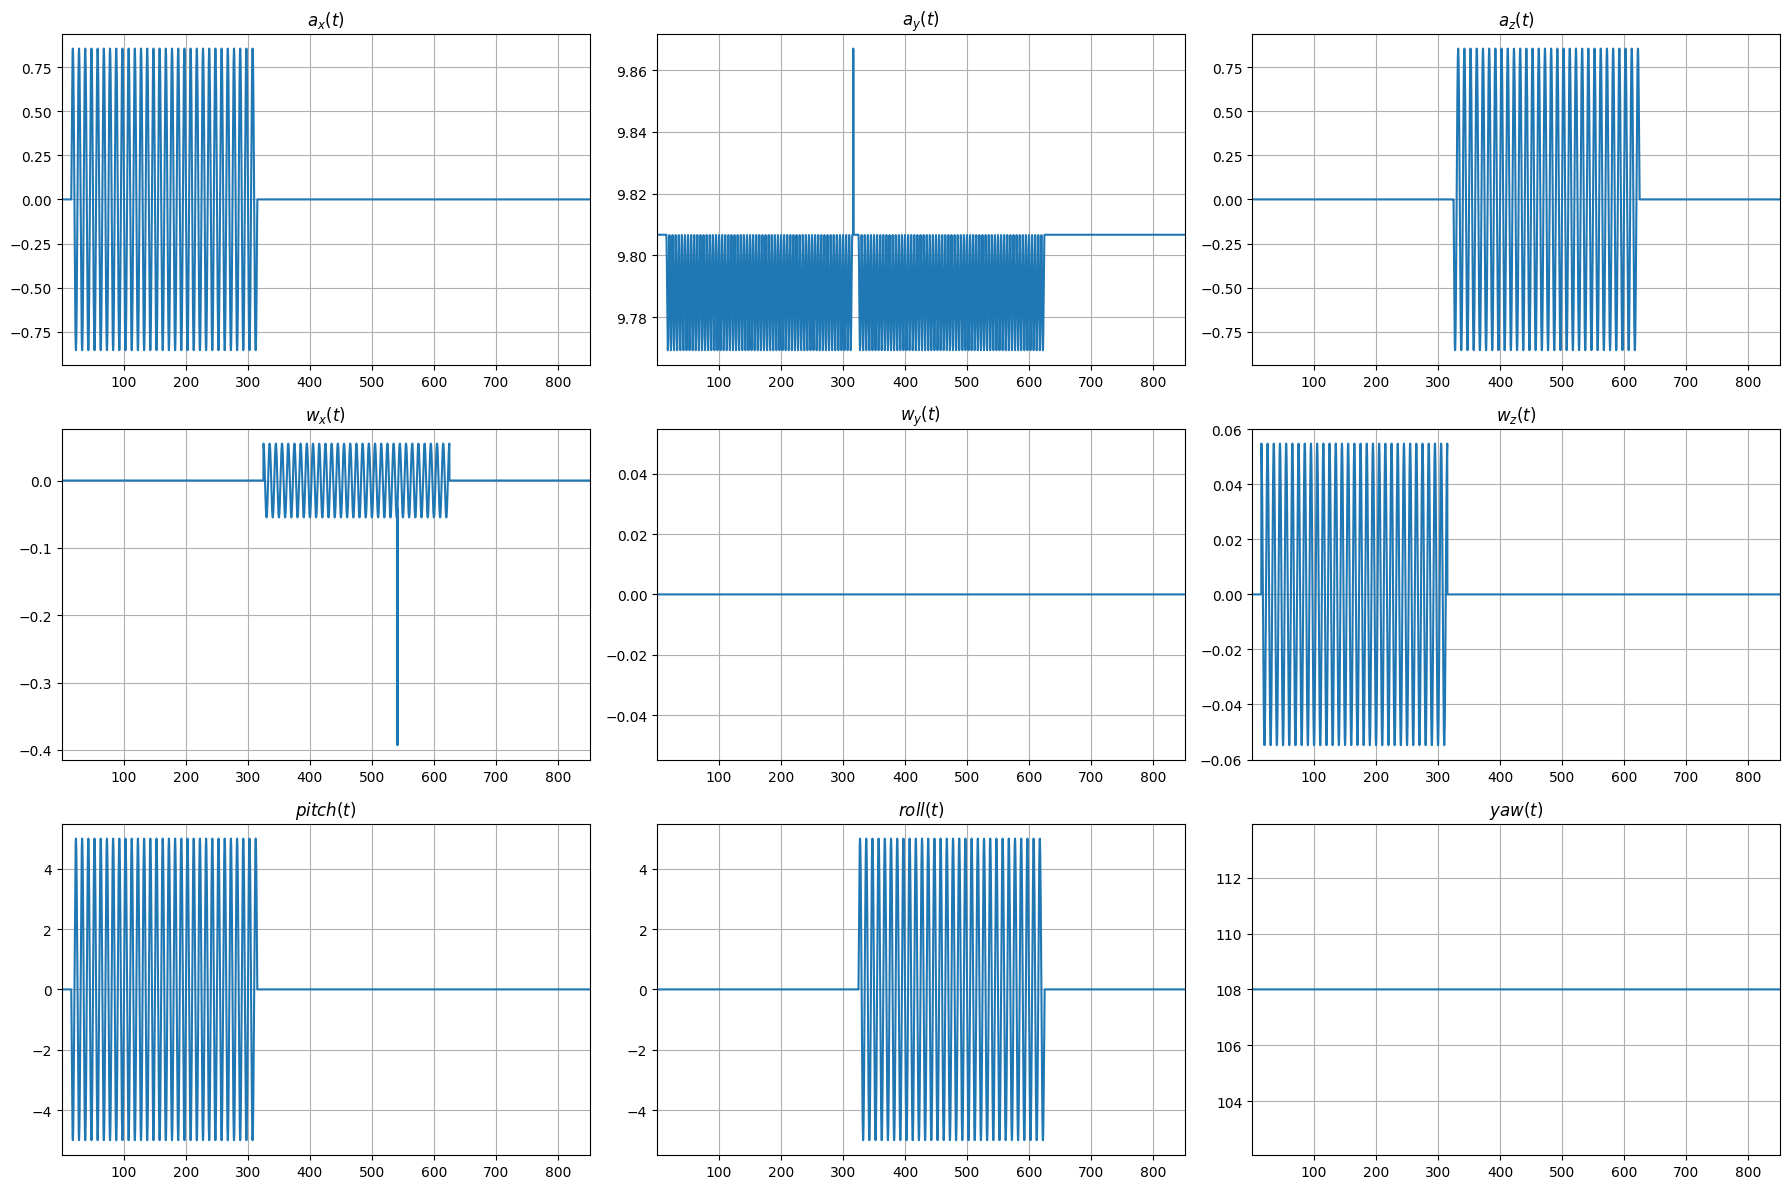

In [103]:
df_ref = pd.read_csv(f'files/test{test}/reference/data.csv')

df_ref = switchColumns(df_ref, 'wy', 'wz')
df_ref = switchColumns(df_ref, 'ay', 'az')

df_ref['pitch'] = -df_ref['pitch']
df_ref['wy']    = -df_ref['wy']
plotAll(df_ref, limits=(0, 0.5))

# JUNTANDO TABELAS

In [104]:
df_target = df_target.rename(columns={col: 'target_' + col for col in df_target.columns if col not in ['time']})
df_target.head()

,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp
0,-0.022520,9.786821,1.551,-0.173754,-0.024,7.152557e-07,0.0074,-0.270526,-0.049690,0.100670,0.00386,43.8
1,-0.021403,9.786437,1.565,-0.173631,-0.022,9.435034e-02,0.0094,-0.269836,-0.042579,0.096062,-0.00114,43.7
2,-0.019379,9.785498,1.572,-0.172351,-0.019,2.007830e-01,0.0064,-0.266464,-0.023901,0.072318,-0.00714,43.8
3,-0.020671,9.784391,1.578,-0.169027,-0.017,2.974703e-01,0.0064,-0.261330,-0.017819,0.028308,-0.00814,43.7
4,-0.023994,9.782251,1.592,-0.165701,-0.014,4.027123e-01,-0.0006,-0.260571,-0.035526,-0.004530,-0.00014,43.7


In [105]:
df_ref = df_ref.rename(columns={col: 'ref_' + col for col in df_ref.columns if col not in ['time']})
df_ref.head()

,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,time,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp
0,0.0,-0.0,108.0,0.0,0.0,7.152557e-07,-0.0,9.8067,0.0,-0.0,0.0,0.0
1,0.0,-0.0,108.0,0.0,0.0,9.435034e-02,-0.0,9.8067,0.0,-0.0,0.0,0.1
2,0.0,-0.0,108.0,0.0,0.0,2.007830e-01,-0.0,9.8067,0.0,-0.0,0.0,0.2
3,0.0,-0.0,108.0,0.0,0.0,2.974703e-01,-0.0,9.8067,0.0,-0.0,0.0,0.3
4,0.0,-0.0,108.0,0.0,0.0,4.027123e-01,-0.0,9.8067,0.0,-0.0,0.0,0.4


In [106]:
df = pd.merge_asof(df_target, df_ref, on='time', direction='nearest')
df

,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp
0,-0.022520,9.786821,1.551,-0.173754,-0.024,7.152557e-07,0.0074,-0.270526,-0.049690,0.100670,0.00386,43.8,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.000
1,-0.021403,9.786437,1.565,-0.173631,-0.022,9.435034e-02,0.0094,-0.269836,-0.042579,0.096062,-0.00114,43.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.100
2,-0.019379,9.785498,1.572,-0.172351,-0.019,2.007830e-01,0.0064,-0.266464,-0.023901,0.072318,-0.00714,43.8,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.200
3,-0.020671,9.784391,1.578,-0.169027,-0.017,2.974703e-01,0.0064,-0.261330,-0.017819,0.028308,-0.00814,43.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.300
4,-0.023994,9.782251,1.592,-0.165701,-0.014,4.027123e-01,-0.0006,-0.260571,-0.035526,-0.004530,-0.00014,43.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17022,-0.026747,9.771511,24.694,-0.197927,-0.006,1.702951e+03,0.0864,-0.247564,0.015916,0.043481,0.13186,44.6,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1702.935
17023,-0.035871,9.776384,24.696,-0.196250,-0.006,1.703046e+03,0.0874,-0.247078,-0.001012,0.061295,0.13286,44.8,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.035
17024,-0.050030,9.779882,24.698,-0.196080,-0.006,1.703146e+03,0.0864,-0.247174,-0.025138,0.067609,0.13186,44.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.135
17025,-0.048188,9.780079,24.699,-0.197638,-0.006,1.703249e+03,0.0854,-0.247640,-0.024167,0.053473,0.13186,44.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.235


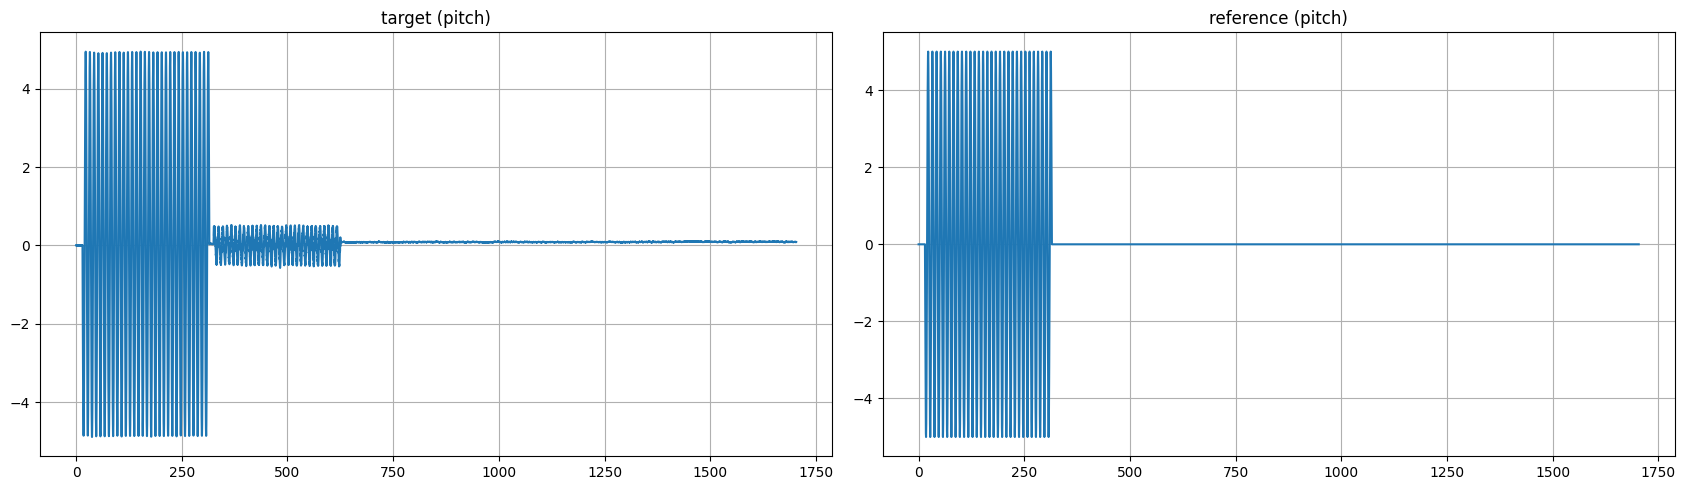

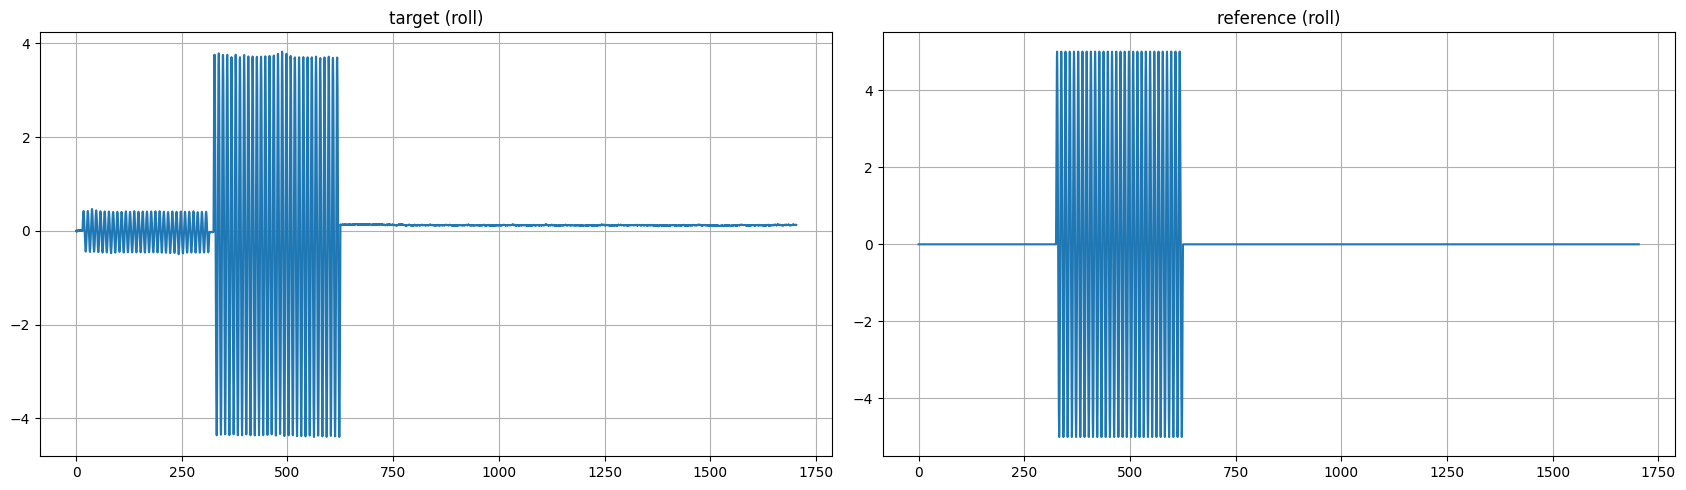

In [107]:
def compareAxis(data, time=None, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)   
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        time_data = time if time is not None else np.array(range(len(values)))
        
        plt.subplot(numRows, numCols, i+1)
        plt.plot(time_data, values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll']:
    compareAxis({
        f'target ({var})':  df[f'target_{var}'], 
        f'reference ({var})': df[f'ref_{var}'],
    }, time=df.time, figsize=(17, 5))

# ENCONTRANDO CATEGORIAS
- status pode ser = 'none' (nenhum/estabilizando), 'pitch' (variando pitch), 'roll' (variando roll), 'static' (parado)
- Implementação da detecção pelos dados utilizando os intervalos com folgas de 10s:

In [108]:
conditions = [
    (df['time'] >= 15) & (df['time'] < 315),  # 300s variando pitch
    (df['time'] >= 325) & (df['time'] < 625), # 300s variando roll
    (df['time'] >= 635)                       # estático (parado)
]

choices = ['pitch', 'roll', 'static']
df['status'] = np.select(conditions, choices, default='none')
df['status'].value_counts()

status
static    10679
pitch      3000
roll       2998
none        350
Name: count, dtype: int64

In [109]:
df

,target_wz,target_az,target_yaw,target_ax,target_h,time,target_pitch,target_ay,target_wx,target_wy,target_roll,target_tmp,ref_wz,ref_az,ref_yaw,ref_ax,ref_h,ref_pitch,ref_ay,ref_wx,ref_wy,ref_roll,ref_tmp,status
0,-0.022520,9.786821,1.551,-0.173754,-0.024,7.152557e-07,0.0074,-0.270526,-0.049690,0.100670,0.00386,43.8,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.000,none
1,-0.021403,9.786437,1.565,-0.173631,-0.022,9.435034e-02,0.0094,-0.269836,-0.042579,0.096062,-0.00114,43.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.100,none
2,-0.019379,9.785498,1.572,-0.172351,-0.019,2.007830e-01,0.0064,-0.266464,-0.023901,0.072318,-0.00714,43.8,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.200,none
3,-0.020671,9.784391,1.578,-0.169027,-0.017,2.974703e-01,0.0064,-0.261330,-0.017819,0.028308,-0.00814,43.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.300,none
4,-0.023994,9.782251,1.592,-0.165701,-0.014,4.027123e-01,-0.0006,-0.260571,-0.035526,-0.004530,-0.00014,43.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,0.400,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17022,-0.026747,9.771511,24.694,-0.197927,-0.006,1.702951e+03,0.0864,-0.247564,0.015916,0.043481,0.13186,44.6,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1702.935,static
17023,-0.035871,9.776384,24.696,-0.196250,-0.006,1.703046e+03,0.0874,-0.247078,-0.001012,0.061295,0.13286,44.8,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.035,static
17024,-0.050030,9.779882,24.698,-0.196080,-0.006,1.703146e+03,0.0864,-0.247174,-0.025138,0.067609,0.13186,44.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.135,static
17025,-0.048188,9.780079,24.699,-0.197638,-0.006,1.703249e+03,0.0854,-0.247640,-0.024167,0.053473,0.13186,44.7,0.0,-0.0,108.0,0.0,0.0,-0.0,9.8067,0.0,-0.0,0.0,1703.235,static


# SALVANDO DADOS

In [110]:
os.makedirs('files', exist_ok=True)
df.to_csv('files/output.csv', index=None)